# EURUSD — Buy Model (Y₁)

**Purpose:** Train the binary BUY sub-model for EURUSD on the H1 timeframe.  
The label asks: *"would a long trade have hit Take Profit before Stop Loss in the next N bars?"*

**Pipeline overview:**
1. Configuration (paths, ATR params, split dates)
2. Load raw H1 data
3. Validate & inspect the dataset
4. Feature engineering (technical indicators) → `df_features`
5. ATR threshold tuning (class balance exploration on training window)
6. Label generation (SL/TP path-dependent labels) → `df_labeled`
7. Chronological split → `df_train` / `df_val` / `df_test`
8. Walk-forward training — XGBoost + LightGBM base models *(next)*
9. Evaluation (cost-aware metrics)
10. Save trained model to `models_bin/`


In [1]:
#imports code
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print(f"Python  : {sys.version}")
print(f"NumPy   : {np.__version__}")
print(f"Pandas  : {pd.__version__}")


Python  : 3.11.13 | packaged by conda-forge | (main, Jun  4 2025, 14:39:58) [MSC v.1943 64 bit (AMD64)]
NumPy   : 2.2.6
Pandas  : 2.3.1


## 1. Configuration

All paths and key parameters live in one place.  
Change `PAIR` or `TIMEFRAME` here to reuse this notebook for other instruments.


In [2]:
from pathlib import Path

# ── Instrument & timeframe ────────────────────────────────────────────────────
PAIR      = "EURUSD"
TIMEFRAME = "H1"

# ── Data paths ────────────────────────────────────────────────────────────────
# Root of the ml-signal-service folder (two levels up from this notebook)
ROOT = Path("../..").resolve()

RAW_DATA_DIR  = ROOT / "data" / "raw" / "mt5" / TIMEFRAME
RAW_FILE      = RAW_DATA_DIR / f"{PAIR}_{TIMEFRAME}.csv"

MODELS_DIR    = ROOT / "models_bin"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ── Label parameters ──────────────────────────────────────────────────────────
# TP = 1.5 × ATR above entry, SL = 1.0 × ATR below entry → R:R = 1.5
# Tune these in Section 5 before generating labels.
ATR_PERIOD   = 14     # bars used to compute ATR(14)
ATR_TP_MULT  = 1.5    # take-profit distance = ATR × ATR_TP_MULT
ATR_SL_MULT  = 1.0    # stop-loss distance   = ATR × ATR_SL_MULT
FORWARD_BARS = 6      # how many H1 bars forward to scan for TP/SL hit

# ── Chronological split boundaries ───────────────────────────────────────────
# Edit ONLY here to change split dates — every downstream step reads from these.
TRAIN_START = "2019-01-01"
TRAIN_END   = "2025-06-30 23:00:00"
VAL_START   = "2025-07-01 00:00:00"
VAL_END     = "2026-01-30 23:00:00"
TEST_START  = "2026-02-01 00:00:00"   # TEST_END = present (all remaining rows)

print(f"Pair       : {PAIR}")
print(f"Timeframe  : {TIMEFRAME}")
print(f"Raw file   : {RAW_FILE}")
print(f"File exists: {RAW_FILE.exists()}")
print(f"Train      : {TRAIN_START}  →  {TRAIN_END}")
print(f"Val        : {VAL_START}  →  {VAL_END}")
print(f"Test       : {TEST_START}  →  present")


Pair       : EURUSD
Timeframe  : H1
Raw file   : C:\Users\dsosa\Documents\fx-prival\ml-signal-service\data\raw\mt5\H1\EURUSD_H1.csv
File exists: True
Train      : 2019-01-01  →  2025-06-30 23:00:00
Val        : 2025-07-01 00:00:00  →  2026-01-30 23:00:00
Test       : 2026-02-01 00:00:00  →  present


## 2. Load Raw Data

Load the MT5 H1 export for EURUSD. The file contains: `datetime, open, high, low, close, volume`.


In [3]:
df = pd.read_csv(
    RAW_FILE,
    parse_dates=["datetime"],   # parse the datetime column directly on load
)

# Ensure rows are in chronological order (MT5 exports are usually sorted, but let's be safe)
df = df.sort_values("datetime").reset_index(drop=True)

print(f"Rows      : {len(df):,}")
print(f"Columns   : {list(df.columns)}")
print(f"Date range: {df['datetime'].min()}  →  {df['datetime'].max()}")


Rows      : 46,697
Columns   : ['datetime', 'open', 'high', 'low', 'close', 'volume']
Date range: 2019-01-02 00:00:00  →  2026-07-03 15:00:00


## 3. Validate the Dataset

Quick sanity checks before touching anything:
- **dtypes** — datetime must be a proper timestamp, OHLCV must be numeric
- **nulls** — no missing values allowed before feature engineering
- **OHLC logic** — high ≥ open/close ≥ low for every bar
- **Duplicates** — no repeated timestamps


In [4]:
# ── 1. Data types ─────────────────────────────────────────────────────────────
print("=== dtypes ===")
print(df.dtypes)

# ── 2. Null check ─────────────────────────────────────────────────────────────
print("\n=== Null values per column ===")
print(df.isnull().sum())

# ── 3. Duplicate timestamps ───────────────────────────────────────────────────
n_dupes = df["datetime"].duplicated().sum()
print(f"\nDuplicate timestamps : {n_dupes}")

# ── 4. OHLC logic check ───────────────────────────────────────────────────────
# Every bar must satisfy: low <= open <= high  and  low <= close <= high
bad_ohlc = df[
    (df["high"] < df["open"])  |
    (df["high"] < df["close"]) |
    (df["low"]  > df["open"])  |
    (df["low"]  > df["close"])
]
print(f"OHLC logic violations: {len(bad_ohlc)}")

# ── 5. Summary ────────────────────────────────────────────────────────────────
print("\n=== Descriptive statistics ===")
df[["open", "high", "low", "close", "volume"]].describe().round(6)


=== dtypes ===
datetime    datetime64[ns]
open               float64
high               float64
low                float64
close              float64
volume               int64
dtype: object

=== Null values per column ===
datetime    0
open        0
high        0
low         0
close       0
volume      0
dtype: int64

Duplicate timestamps : 0
OHLC logic violations: 0

=== Descriptive statistics ===


,open,high,low,close,volume
count,46697.000000,46697.000000,46697.000000,46697.000000,46697.000000
mean,1.116582,1.117274,1.115904,1.116588,3200.528299
std,0.053335,0.053266,0.053396,0.053334,3281.333781
min,0.953860,0.955880,0.953530,0.953860,1.000000
25%,1.081580,1.082250,1.081020,1.081600,1271.000000
50%,1.113440,1.113940,1.112850,1.113440,2303.000000
75%,1.161860,1.162490,1.161230,1.161860,3982.000000
max,1.233960,1.234890,1.233280,1.233960,75413.000000


In [5]:
# Quick preview — first and last 3 bars
print("=== First 3 bars ===")
display(df.head(3))

print("=== Last 3 bars ===")
display(df.tail(3))


=== First 3 bars ===


,datetime,open,high,low,close,volume
0,2019-01-02 00:00:00,1.14624,1.14638,1.14591,1.14603,856
1,2019-01-02 01:00:00,1.14616,1.14672,1.14552,1.14605,1821
2,2019-01-02 02:00:00,1.14605,1.14620,1.14538,1.14555,1509


=== Last 3 bars ===


,datetime,open,high,low,close,volume
46694,2026-07-03 13:00:00,1.14401,1.14494,1.14399,1.14462,910
46695,2026-07-03 14:00:00,1.14462,1.14565,1.14456,1.14498,1153
46696,2026-07-03 15:00:00,1.14500,1.14522,1.14457,1.14463,1234


In [6]:
# Distribution of bars per year — useful to spot thin years (data gaps / late exports)
df["year"] = df["datetime"].dt.year

bars_per_year = df.groupby("year").size().rename("bars")
print(bars_per_year.to_string())

# A full trading year on H1 is roughly 6,000–6,500 bars (Mon–Fri, ~24h/day)
# Flag any year below 5,000 as potentially incomplete
low_coverage = bars_per_year[bars_per_year < 5000]
if not low_coverage.empty:
    print(f"\n⚠ Years with < 5,000 bars (possibly incomplete): {low_coverage.index.tolist()}")
else:
    print("\n✓ All years have adequate bar coverage.")

# Drop the helper column — we don't need it in the feature set
df.drop(columns=["year"], inplace=True)


year
2019    6216
2020    6240
2021    6240
2022    6216
2023    6192
2024    6240
2025    6217
2026    3136

⚠ Years with < 5,000 bars (possibly incomplete): [2026]


## 4. Feature Engineering Function

In [7]:
def compute_features(data: pd.DataFrame) -> pd.DataFrame:
    """
    Compute all technical features from raw H1 OHLCV data.

    Parameters
    ----------
    data : pd.DataFrame
        Must contain columns: datetime, open, high, low, close, volume
        Rows must be sorted chronologically (oldest first).

    Returns
    -------
    pd.DataFrame
        Original columns + all feature columns.
        Rows with NaN (caused by rolling windows at the start) are dropped.
    """
    df = data.copy()

    # ── 1. Time features ──────────────────────────────────────────────────────
    df["hour"]        = df["datetime"].dt.hour
    df["day_of_week"] = df["datetime"].dt.dayofweek   # 0=Mon ... 4=Fri
    df["month"]       = df["datetime"].dt.month

    # Cyclical encoding — prevents the model treating 23:00 and 0:00 as far apart
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["dow_sin"]  = np.sin(2 * np.pi * df["day_of_week"] / 5)
    df["dow_cos"]  = np.cos(2 * np.pi * df["day_of_week"] / 5)

    # FX session binary flags (approximate UTC times)
    _h = df["hour"]
    df["session_asian"]   = ((_h >= 0)  & (_h < 7)).astype(int)   # quiet low-liquidity hours
    df["session_london"]  = ((_h >= 7)  & (_h < 16)).astype(int)  # London open
    df["session_ny"]      = ((_h >= 13) & (_h < 22)).astype(int)  # New York open
    df["session_overlap"] = ((_h >= 13) & (_h < 17)).astype(int)  # London-NY overlap (highest liquidity)

    # ── 2. Candle structure ───────────────────────────────────────────────────
    df["body_size"]   = abs(df["close"] - df["open"])
    df["price_range"] = df["high"] - df["low"]
    df["upper_wick"]  = df["high"] - df[["open", "close"]].max(axis=1)
    df["lower_wick"]  = df[["open", "close"]].min(axis=1) - df["low"]
    df["body_ratio"]  = df["body_size"] / df["price_range"].replace(0, np.nan)

    # ── 3. Moving averages ────────────────────────────────────────────────────
    for w in [10, 20, 50]:
        df[f"sma_{w}"] = df["close"].rolling(w).mean()

    for s in [10, 20, 50, 100, 200]:
        df[f"ema_{s}"] = df["close"].ewm(span=s, adjust=False).mean()

    df["close_vs_ema50"]  = (df["close"] - df["ema_50"])  / df["close"]
    df["close_vs_ema200"] = (df["close"] - df["ema_200"]) / df["close"]

    # ── 4. Momentum oscillators ───────────────────────────────────────────────
    delta   = df["close"].diff()
    gain    = delta.clip(lower=0)
    loss    = (-delta).clip(lower=0)
    avg_g   = gain.rolling(14).mean()
    avg_l   = loss.rolling(14).mean()
    rs      = avg_g / avg_l.replace(0, np.nan)
    df["rsi_14"] = 100 - (100 / (1 + rs))

    low14   = df["low"].rolling(14).min()
    high14  = df["high"].rolling(14).max()
    df["stoch_k"]    = 100 * (df["close"] - low14) / (high14 - low14).replace(0, np.nan)
    df["stoch_d"]    = df["stoch_k"].rolling(3).mean()
    df["williams_r"] = -100 * (high14 - df["close"]) / (high14 - low14).replace(0, np.nan)

    ema12              = df["close"].ewm(span=12, adjust=False).mean()
    ema26              = df["close"].ewm(span=26, adjust=False).mean()
    df["macd"]         = ema12 - ema26
    df["macd_sig"]     = df["macd"].ewm(span=9, adjust=False).mean()
    df["macd_hist"]    = df["macd"] - df["macd_sig"]
    df["macd_hist_slope"] = df["macd_hist"].diff()

    # ── 5. Volatility ─────────────────────────────────────────────────────────
    high_low   = df["high"] - df["low"]
    high_pc    = (df["high"] - df["close"].shift()).abs()
    low_pc     = (df["low"]  - df["close"].shift()).abs()
    true_range = pd.concat([high_low, high_pc, low_pc], axis=1).max(axis=1)
    df["atr_14"] = true_range.rolling(ATR_PERIOD).mean()

    # ATR regime: >1.2 = high vol, <0.8 = low vol, ~1.0 = normal
    df["atr_regime"] = df["atr_14"] / df["atr_14"].rolling(50).mean()

    bb_mid          = df["close"].rolling(20).mean()
    bb_std          = df["close"].rolling(20).std()
    df["bb_upper"]  = bb_mid + 2 * bb_std
    df["bb_lower"]  = bb_mid - 2 * bb_std
    df["bb_width"]  = (df["bb_upper"] - df["bb_lower"]) / bb_mid
    df["bb_pct"]    = (df["close"] - df["bb_lower"]) / (df["bb_upper"] - df["bb_lower"]).replace(0, np.nan)

    for w in [10, 20, 50]:
        df[f"rolling_std_{w}"] = df["close"].rolling(w).std()

    # ── 6. Trend strength ─────────────────────────────────────────────────────
    plus_dm  = df["high"].diff().clip(lower=0)
    minus_dm = (-df["low"].diff()).clip(lower=0)
    plus_dm  = plus_dm.where(plus_dm > minus_dm, 0)
    minus_dm = minus_dm.where(minus_dm > plus_dm, 0)
    atr_adx  = true_range.rolling(14).mean()
    plus_di  = 100 * (plus_dm.rolling(14).mean()  / atr_adx.replace(0, np.nan))
    minus_di = 100 * (minus_dm.rolling(14).mean() / atr_adx.replace(0, np.nan))
    dx       = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di).replace(0, np.nan)
    df["adx_14"]   = dx.rolling(14).mean()
    df["plus_di"]  = plus_di
    df["minus_di"] = minus_di

    tp = (df["high"] + df["low"] + df["close"]) / 3
    df["cci_20"]     = (tp - tp.rolling(20).mean()) / (0.015 * tp.rolling(20).std())
    df["roc_10"]     = df["close"].pct_change(10) * 100
    df["momentum_10"] = df["close"] - df["close"].shift(10)

    # ── 7. Volume ─────────────────────────────────────────────────────────────
    df["obv"]          = (np.sign(df["close"].diff()) * df["volume"]).fillna(0).cumsum()
    vol_ma20           = df["volume"].rolling(20).mean()
    df["volume_ratio"] = df["volume"] / vol_ma20.replace(0, np.nan)

    # ── 8. Lagged features ────────────────────────────────────────────────────
    for lag in [1, 2, 3, 5]:
        df[f"close_lag_{lag}"]  = df["close"].shift(lag)
        df[f"rsi_lag_{lag}"]    = df["rsi_14"].shift(lag)
        df[f"atr_lag_{lag}"]    = df["atr_14"].shift(lag)
        df[f"volume_lag_{lag}"] = df["volume"].shift(lag)

    # ── 9. Price-change returns ───────────────────────────────────────────────
    for p in [1, 5, 10]:
        df[f"return_{p}b"] = df["close"].pct_change(p)

    # ── 10. D1 context (resampled from H1, no leakage) ───────────────────────
    # Resample H1 to daily OHLCV and compute D1 trend indicators.
    # Values are shifted 1 day before merging: H1 bars on day T see day T-1's
    # D1 close — yesterday's trend information only.
    _d1 = (
        df.set_index("datetime")[["open", "high", "low", "close", "volume"]]
        .resample("1D")
        .agg({"open": "first", "high": "max", "low": "min",
              "close": "last", "volume": "sum"})
        .dropna()
    )
    _d1["d1_ema20"]  = _d1["close"].ewm(span=20, adjust=False).mean()
    _d1["d1_ema50"]  = _d1["close"].ewm(span=50, adjust=False).mean()
    _d1["d1_trend"]  = (_d1["d1_ema20"] > _d1["d1_ema50"]).astype(int)  # 1=uptrend, 0=downtrend
    _dd = _d1["close"].diff()
    _d1["d1_rsi"]    = 100 - 100 / (
        1 + _dd.clip(lower=0).rolling(14).mean()
          / (-_dd).clip(lower=0).rolling(14).mean().replace(0, np.nan)
    )
    _d1["d1_close_vs_ema20"] = (_d1["close"] - _d1["d1_ema20"]) / _d1["close"]

    _d1_cols    = ["d1_ema20", "d1_ema50", "d1_trend", "d1_rsi", "d1_close_vs_ema20"]
    _d1_shifted = (
        _d1[_d1_cols]
        .shift(1)                                         # yesterday's data only
        .reset_index()
        .rename(columns={"datetime": "_d1_date"})
    )

    # ── 11. Intraday context ──────────────────────────────────────────────────
    # Day open = first H1 bar's open for each calendar day.
    # Every bar sees today's opening price (no leakage — it opened before this bar).
    df["_date"]   = df["datetime"].dt.normalize()
    _day_open     = df.groupby("_date")["open"].first().rename("_day_open")
    df            = df.join(_day_open, on="_date")
    df["close_vs_day_open"] = (df["close"] - df["_day_open"]) / df["_day_open"]

    # Merge D1 features back to H1 (matched by midnight timestamp of each day)
    df = df.merge(_d1_shifted, left_on="_date", right_on="_d1_date", how="left")
    df.drop(columns=["_date", "_d1_date", "_day_open"], inplace=True)

    # ── Drop NaN rows ─────────────────────────────────────────────────────────
    # The longest window is EMA(200) + D1 EMA(50 days), so first ~250 bars drop.
    n_before = len(df)
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)
    n_dropped = n_before - len(df)
    print(f"Rows dropped (NaN warm-up): {n_dropped:,}  |  Rows remaining: {len(df):,}")

    return df


In [8]:
# Apply feature engineering to the raw dataframe
df_features = compute_features(df)

# ── Quick inspection ──────────────────────────────────────────────────────────
print(f"\nFeature matrix shape : {df_features.shape}")
print(f"Date range           : {df_features['datetime'].min()}  →  {df_features['datetime'].max()}")
print(f"\nAll columns ({len(df_features.columns)}):")
for col in df_features.columns:
    print(f"  {col}")


Rows dropped (NaN warm-up): 361  |  Rows remaining: 46,336

Feature matrix shape : (46336, 82)
Date range           : 2019-01-23 00:00:00  →  2026-07-03 15:00:00

All columns (82):
  datetime
  open
  high
  low
  close
  volume
  hour
  day_of_week
  month
  hour_sin
  hour_cos
  dow_sin
  dow_cos
  session_asian
  session_london
  session_ny
  session_overlap
  body_size
  price_range
  upper_wick
  lower_wick
  body_ratio
  sma_10
  sma_20
  sma_50
  ema_10
  ema_20
  ema_50
  ema_100
  ema_200
  close_vs_ema50
  close_vs_ema200
  rsi_14
  stoch_k
  stoch_d
  williams_r
  macd
  macd_sig
  macd_hist
  macd_hist_slope
  atr_14
  atr_regime
  bb_upper
  bb_lower
  bb_width
  bb_pct
  rolling_std_10
  rolling_std_20
  rolling_std_50
  adx_14
  plus_di
  minus_di
  cci_20
  roc_10
  momentum_10
  obv
  volume_ratio
  close_lag_1
  rsi_lag_1
  atr_lag_1
  volume_lag_1
  close_lag_2
  rsi_lag_2
  atr_lag_2
  volume_lag_2
  close_lag_3
  rsi_lag_3
  atr_lag_3
  volume_lag_3
  close_lag_5
 

## 5. ATR Threshold Tuning

Before locking in `ATR_TP_MULT` and `ATR_SL_MULT`, we explore how different multiplier
combinations affect the class balance **on the training date window only** (2019–2024).

Two things to watch per combination:
- **% BUY** — target range: 20–30%. Below 15% → too rare to train on. Above 40% → signal is noise.
- **Breakeven win rate** — minimum precision the model must achieve to be profitable:
  $$\text{Breakeven} = \frac{SL\_mult}{TP\_mult + SL\_mult}$$

All exploration uses `TRAIN_START`/`TRAIN_END` from config to filter results —
validation and test date windows are never touched.


Fixed SL multiplier = 1.0

 TP mult     R:R    % BUY   Breakeven   In target?
-------------------------------------------------------
    0.50    0.50    58.4%       66.7%            ✗
    0.75    0.75    46.8%       57.1%            ✗
    1.00    1.00    37.2%       50.0%            ✗
    1.25    1.25    29.8%       44.4%            ✓
    1.50    1.50    24.2%       40.0%            ✓
    1.75    1.75    20.0%       36.4%            ✓
    2.00    2.00    16.6%       33.3%            ✓
    2.50    2.50    11.8%       28.6%            ✗
    3.00    3.00     8.6%       25.0%            ✗


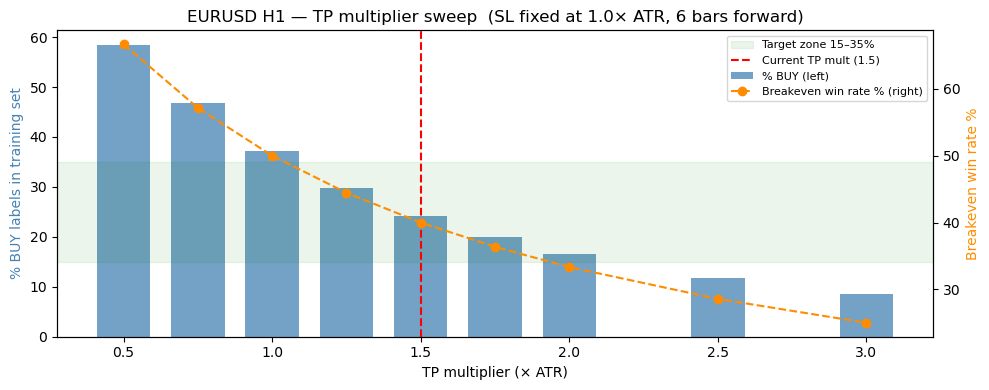

In [9]:
def _label_rate(features_df, train_start, train_end, forward_bars, tp_mult, sl_mult):
    """
    Lightweight helper: compute % BUY labels for a given multiplier pair.
    Labels are generated on the full feature set (so boundary rows are complete),
    then filtered to the training window for the balance calculation.
    """
    close = features_df["close"].values
    high  = features_df["high"].values
    low   = features_df["low"].values
    atr   = features_df["atr_14"].values
    n     = len(features_df)

    labels = np.full(n, np.nan)
    for i in range(n - forward_bars):
        tp_level = close[i] + atr[i] * tp_mult
        sl_level = close[i] - atr[i] * sl_mult
        result = 0
        for j in range(1, forward_bars + 1):
            k = i + j
            tp_hit = high[k] >= tp_level
            sl_hit = low[k]  <= sl_level
            if tp_hit and sl_hit:
                result = 0; break
            elif tp_hit:
                result = 1; break
            elif sl_hit:
                result = 0; break
        labels[i] = result

    # Filter to train window only
    mask  = (features_df["datetime"] >= train_start) & (features_df["datetime"] <= train_end)
    train_labels = labels[mask.values]
    valid = train_labels[~np.isnan(train_labels)]
    return valid.mean() * 100   # % BUY


# ── 1-D sweep: vary TP multiplier, fix SL = 1.0 ──────────────────────────────
tp_candidates = [0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]
sl_fixed      = 1.0

print(f"Fixed SL multiplier = {sl_fixed}\n")
print(f"{'TP mult':>8}  {'R:R':>6}  {'% BUY':>7}  {'Breakeven':>10}  {'In target?':>11}")
print("-" * 55)

tp_sweep_results = []
for tp in tp_candidates:
    pct_buy    = _label_rate(df_features, TRAIN_START, TRAIN_END, FORWARD_BARS, tp, sl_fixed)
    rr         = tp / sl_fixed
    breakeven  = sl_fixed / (tp + sl_fixed) * 100
    in_target  = "✓" if 15 <= pct_buy <= 35 else "✗"
    tp_sweep_results.append((tp, rr, pct_buy, breakeven))
    print(f"{tp:>8.2f}  {rr:>6.2f}  {pct_buy:>6.1f}%  {breakeven:>9.1f}%  {in_target:>11}")

# ── Chart ─────────────────────────────────────────────────────────────────────
tps, rrs, pcts, bes = zip(*tp_sweep_results)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

bars = ax1.bar(tps, pcts, width=0.18, color="steelblue", alpha=0.75, label="% BUY (left)")
ax1.axhspan(15, 35, alpha=0.08, color="green", label="Target zone 15–35%")
ax1.axvline(ATR_TP_MULT, color="red", linestyle="--", linewidth=1.5, label=f"Current TP mult ({ATR_TP_MULT})")
ax2.plot(tps, bes, "o--", color="darkorange", linewidth=1.5, label="Breakeven win rate % (right)")

ax1.set_xlabel("TP multiplier (× ATR)")
ax1.set_ylabel("% BUY labels in training set", color="steelblue")
ax2.set_ylabel("Breakeven win rate %", color="darkorange")
ax1.set_title(f"{PAIR} {TIMEFRAME} — TP multiplier sweep  (SL fixed at {sl_fixed}× ATR, {FORWARD_BARS} bars forward)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()


Computing grid (may take ~20 seconds)...
Done.



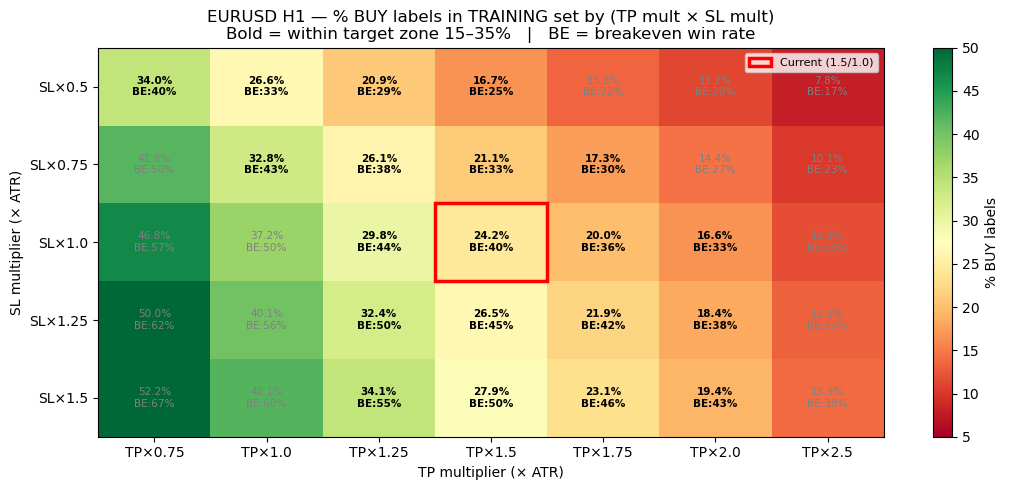


Reading the grid:
  Green cell  = high % BUY  |  Red cell = low % BUY
  Bold values = within target zone (15–35%) — safe to use
  BE          = min precision the model must achieve to be profitable

Current config: TP×1.5 / SL×1.0  →  R:R = 1.5  |  Breakeven = 40.0%


In [10]:
# ── 2-D grid: vary both TP and SL multipliers ────────────────────────────────
tp_grid = [0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5]
sl_grid = [0.5,  0.75, 1.0, 1.25, 1.5]

grid_pct = np.zeros((len(sl_grid), len(tp_grid)))

print("Computing grid (may take ~20 seconds)...")
for i, sl in enumerate(sl_grid):
    for j, tp in enumerate(tp_grid):
        grid_pct[i, j] = _label_rate(
            df_features, TRAIN_START, TRAIN_END, FORWARD_BARS, tp, sl
        )
print("Done.\n")

# ── Heatmap ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

im = ax.imshow(grid_pct, cmap="RdYlGn", vmin=5, vmax=50, aspect="auto")
plt.colorbar(im, ax=ax, label="% BUY labels")

# Annotate each cell with the % value and a breakeven marker
for i, sl in enumerate(sl_grid):
    for j, tp in enumerate(tp_grid):
        pct = grid_pct[i, j]
        be  = sl / (tp + sl) * 100
        in_range = 15 <= pct <= 35
        cell_text = f"{pct:.1f}%\nBE:{be:.0f}%"
        color = "black" if in_range else "grey"
        weight = "bold" if in_range else "normal"
        ax.text(j, i, cell_text, ha="center", va="center",
                fontsize=7.5, color=color, fontweight=weight)

# Mark the currently selected multipliers
if ATR_TP_MULT in tp_grid and ATR_SL_MULT in sl_grid:
    ci = sl_grid.index(ATR_SL_MULT)
    cj = tp_grid.index(ATR_TP_MULT)
    ax.add_patch(plt.Rectangle((cj - 0.5, ci - 0.5), 1, 1,
                                fill=False, edgecolor="red", linewidth=2.5,
                                label=f"Current ({ATR_TP_MULT}/{ATR_SL_MULT})"))
    ax.legend(loc="upper right", fontsize=8)

ax.set_xticks(range(len(tp_grid)))
ax.set_xticklabels([f"TP×{v}" for v in tp_grid])
ax.set_yticks(range(len(sl_grid)))
ax.set_yticklabels([f"SL×{v}" for v in sl_grid])
ax.set_xlabel("TP multiplier (× ATR)")
ax.set_ylabel("SL multiplier (× ATR)")
ax.set_title(
    f"{PAIR} {TIMEFRAME} — % BUY labels in TRAINING set by (TP mult × SL mult)\n"
    f"Bold = within target zone 15–35%   |   BE = breakeven win rate"
)
plt.tight_layout()
plt.show()

print("\nReading the grid:")
print("  Green cell  = high % BUY  |  Red cell = low % BUY")
print("  Bold values = within target zone (15–35%) — safe to use")
print("  BE          = min precision the model must achieve to be profitable")
print(f"\nCurrent config: TP×{ATR_TP_MULT} / SL×{ATR_SL_MULT}  →  "
      f"R:R = {ATR_TP_MULT/ATR_SL_MULT:.1f}  |  "
      f"Breakeven = {ATR_SL_MULT/(ATR_TP_MULT+ATR_SL_MULT)*100:.1f}%")


## 6. Label Generation — Y₁ (BUY)

### What exactly are we predicting?

For each H1 bar `t`, we simulate entering a **long trade at `close[t]`** and ask:  
*"Would this trade have hit Take Profit before Stop Loss within the next 10 hours?"*

### Label mechanics

| Parameter | Formula | Example (ATR = 0.0008) |
|---|---|---|
| Entry price | `close[t]` | 1.0800 |
| TP level | `close[t] + ATR_14[t] × 1.5` | 1.0800 + 0.0012 = **1.0812** |
| SL level | `close[t] − ATR_14[t] × 1.0` | 1.0800 − 0.0008 = **1.0792** |
| Forward window | bars `t+1` → `t+10` | next 10 H1 bars |

Each bar in the window is checked in order (t+1 first, t+10 last):

```
high[t+j] ≥ TP  AND  low[t+j] ≤ SL  → same-bar ambiguity → label = 0  (conservative)
high[t+j] ≥ TP  (only)               → TP hit first       → label = 1  ✓
low[t+j]  ≤ SL  (only)               → SL hit first       → label = 0  ✗
neither hit in all 10 bars            → no outcome         → label = 0
```

**label = 1** → "BUY opportunity — this long trade would have been profitable"  
**label = 0** → "Not a BUY opportunity" (SL hit, timeout, or ambiguous bar)

### Risk-to-reward ratio
$$R:R = \frac{ATR\_TP\_MULT}{ATR\_SL\_MULT} = \frac{1.5}{1.0} = 1.5$$

The threshold is **adaptive per bar** — it scales with ATR, so a label-1 in a volatile session
requires a bigger move than in a quiet session.

### Why label the full dataset then split?
The label for bar `t` uses only the raw `high`/`low` of future bars as the **outcome** to predict.
Those future values never appear as model input features (all features are backward-looking).
There is no data leakage. The last `FORWARD_BARS` rows get `NaN` labels (no complete window) and are dropped.


In [11]:
def generate_buy_labels(
    data: pd.DataFrame,
    forward_bars: int,
    atr_tp_mult: float,
    atr_sl_mult: float,
) -> pd.DataFrame:
    """
    Generate binary BUY labels for each bar using a forward SL/TP scan.

    Parameters
    ----------
    data         : DataFrame with columns close, high, low, atr_14 (sorted oldest→newest)
    forward_bars : how many H1 bars ahead to look for TP or SL hit
    atr_tp_mult  : TP = close[t] + atr_14[t] * atr_tp_mult
    atr_sl_mult  : SL = close[t] - atr_14[t] * atr_sl_mult

    Returns
    -------
    DataFrame with a new column `buy_label` (1.0 or 0.0).
    The last `forward_bars` rows (NaN labels) are dropped.
    """
    df = data.copy()
    n = len(df)

    # Work with numpy arrays for speed — 46k × 10 iterations is trivial
    close = df["close"].values
    high  = df["high"].values
    low   = df["low"].values
    atr   = df["atr_14"].values

    labels = np.full(n, np.nan)   # NaN until we can compute a complete window

    for i in range(n - forward_bars):
        entry    = close[i]
        tp_level = entry + atr[i] * atr_tp_mult   # price must reach this to win
        sl_level = entry - atr[i] * atr_sl_mult   # price must NOT fall here first

        result = 0   # default: label = 0 (no buy / timeout)

        for j in range(1, forward_bars + 1):
            k = i + j
            tp_hit = high[k] >= tp_level
            sl_hit = low[k]  <= sl_level

            if tp_hit and sl_hit:
                # Both extremes on the same bar — H1 resolution can't tell which came first.
                # Conservative choice: assume SL was hit first → not a clean buy.
                result = 0
                break
            elif tp_hit:
                result = 1   # TP reached before SL → valid buy opportunity
                break
            elif sl_hit:
                result = 0   # SL triggered before TP → trade would have lost
                break
            # Neither hit → continue scanning the next bar

        labels[i] = result

    # Attach the label column
    df["buy_label"] = labels

    # Drop the last FORWARD_BARS rows — they have no complete forward window (NaN)
    n_before = len(df)
    df.dropna(subset=["buy_label"], inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"Rows with complete label : {len(df):,}  (dropped {n_before - len(df)} tail rows)")

    return df


## 7. Chronological Split — Train / Validation / Test

Labels are generated first on the full `df_features`, then the dataset is split by date.
This is the correct order — labels use future price as the **target**, not as a feature,
so there is no data leakage.

| Set | Period | Purpose |
|---|---|---|
| **Train** | 2019-01-01 → 2024-12-31 | Model fitting |
| **Validation** | 2025-01-01 → 2025-12-31 | Model selection, threshold validation |
| **Test** | 2026-01-01 → present | Final hold-out — open only once at the very end |

> Split dates are defined in the **Configuration** cell — change them there, not here.


In [12]:
# Split date constants are defined in the Configuration cell (cell 4).
# The final labeled splits (df_train, df_val, df_test) are created in the cell below
# after labels have been generated — that is the only version used for training.
print(f"Train  : {TRAIN_START}  →  {TRAIN_END}")
print(f"Val    : {VAL_START}  →  {VAL_END}")
print(f"Test   : {TEST_START}  →  present")


Train  : 2019-01-01  →  2025-06-30 23:00:00
Val    : 2025-07-01 00:00:00  →  2026-01-30 23:00:00
Test   : 2026-02-01 00:00:00  →  present


Rows with complete label : 46,330  (dropped 6 tail rows)

=== Class balance ===
Split          Total   label=1   label=0    % Buy
--------------------------------------------------
Train         40,056     9,703    30,353    24.2%
Validation     3,648       891     2,757    24.4%
Test           2,626       640     1,986    24.4%
All           46,330    11,234    35,096    24.2%


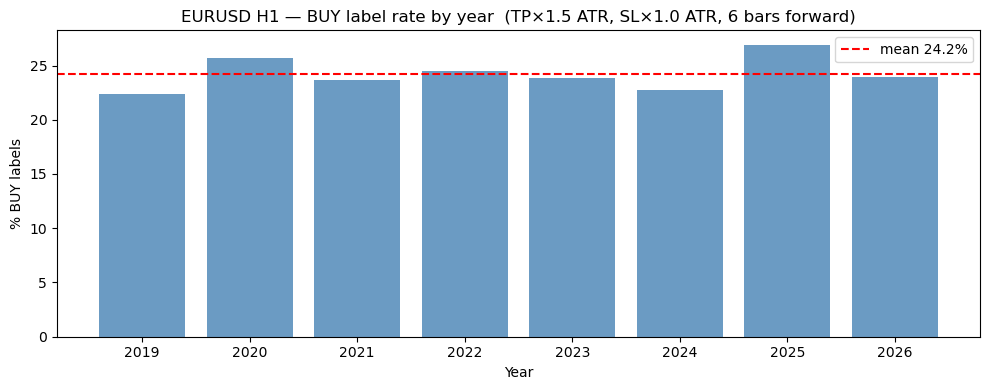

In [13]:
# ── Generate labels on the full feature dataset ───────────────────────────────
df_labeled = generate_buy_labels(
    df_features,
    forward_bars = FORWARD_BARS,
    atr_tp_mult  = ATR_TP_MULT,
    atr_sl_mult  = ATR_SL_MULT,
)

# ── Re-apply chronological splits now that labels exist ──────────────────────
# (same date boundaries as before — just re-filtering the labeled dataframe)
df_train = df_labeled[(df_labeled["datetime"] >= TRAIN_START) & (df_labeled["datetime"] <= TRAIN_END)].copy().reset_index(drop=True)
df_val   = df_labeled[(df_labeled["datetime"] >= VAL_START)   & (df_labeled["datetime"] <= VAL_END)].copy().reset_index(drop=True)
df_test  = df_labeled[df_labeled["datetime"]  >= TEST_START].copy().reset_index(drop=True)

# ── Class balance check ───────────────────────────────────────────────────────
# Target: ~20-30% label=1. Too low → model never fires. Too high → labels are noise.
print("\n=== Class balance ===")
print(f"{'Split':<12} {'Total':>7}  {'label=1':>8}  {'label=0':>8}  {'% Buy':>7}")
print("-" * 50)
for split_name, split_df in [("Train", df_train), ("Validation", df_val), ("Test", df_test), ("All", df_labeled)]:
    n      = len(split_df)
    n_buy  = int(split_df["buy_label"].sum())
    n_no   = n - n_buy
    pct    = n_buy / n * 100
    print(f"{split_name:<12} {n:>7,}  {n_buy:>8,}  {n_no:>8,}  {pct:>6.1f}%")

# ── Visual check: label distribution by year ─────────────────────────────────
df_labeled["year"] = df_labeled["datetime"].dt.year
yearly = df_labeled.groupby("year")["buy_label"].agg(["sum", "count"])
yearly["pct_buy"] = yearly["sum"] / yearly["count"] * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(yearly.index, yearly["pct_buy"], color="steelblue", alpha=0.8)
ax.axhline(yearly["pct_buy"].mean(), color="red", linestyle="--", label=f"mean {yearly['pct_buy'].mean():.1f}%")
ax.set_xlabel("Year")
ax.set_ylabel("% BUY labels")
ax.set_title(f"{PAIR} {TIMEFRAME} — BUY label rate by year  (TP×{ATR_TP_MULT} ATR, SL×{ATR_SL_MULT} ATR, {FORWARD_BARS} bars forward)")
ax.legend()
plt.tight_layout()
plt.show()

df_labeled.drop(columns=["year"], inplace=True)


## 8. Training Process

### 8.1 Feature selection

**Method — noise features + voting system.**

We inject random *noise* features (columns with no real predictive value) alongside the
real features, then train several models and read their feature importances. Any real
feature that scores **below the noise** is useless and gets dropped.

Three models vote independently:
- **Random Forest** (tree importance)
- **LightGBM** (tree importance)
- **Logistic Regression** (scaled — `|coef|` as importance)

A feature is kept only if it consistently beats the noise across the models/strategies.

> Everything here is fit on **`df_train` only**. Validation and test sets are never touched
> during feature selection — otherwise we would leak future information.


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb

# ── Build the feature list ────────────────────────────────────────────────────
# Everything except raw OHLCV, datetime and the label is a candidate feature.
NON_FEATURES = ["datetime", "open", "high", "low", "close", "volume", "buy_label"]
feature_cols = [c for c in df_train.columns if c not in NON_FEATURES]

# Training matrix — TRAIN SET ONLY
X_train = df_train[feature_cols].copy()
y_train = df_train["buy_label"].astype(int)

print(f"Real features : {len(feature_cols)}")
print(f"X_train shape : {X_train.shape}")
print(f"Positive rate : {y_train.mean()*100:.1f}%")

# ── Generate noise features ───────────────────────────────────────────────────
# Random columns with no real signal. If a real feature can't beat these, drop it.
np.random.seed(42)
n = len(X_train)

noise = {
    "noise_gaussian_1": np.random.normal(0, 1, n),
    "noise_gaussian_2": np.random.normal(0, 2, n),
    "noise_gaussian_3": np.random.normal(5, 1, n),
    "noise_uniform_1":  np.random.uniform(-1, 1, n),
    "noise_uniform_2":  np.random.uniform(-10, 10, n),
    "noise_poisson_1":  np.random.poisson(3, n),
    "noise_poisson_2":  np.random.poisson(6, n),
    "noise_random_walk": np.cumsum(np.random.normal(0, 1, n)),
    "noise_sinusoidal": np.sin(np.linspace(0, 10, n)) + np.random.normal(0, 0.1, n),
}
noise_features = list(noise.keys())

# X augmented with the noise columns
X_noise = X_train.copy()
for name, values in noise.items():
    X_noise[name] = values

print(f"Noise features added : {len(noise_features)}")
print(f"X_noise shape        : {X_noise.shape}")


Real features : 76
X_train shape : (40056, 76)
Positive rate : 24.2%
Noise features added : 9
X_noise shape        : (40056, 85)


In [15]:
# ── Train three models to extract feature importances ─────────────────────────
# class_weight="balanced" handles the ~30/70 imbalance without resampling.

# 1) Random Forest
print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=300, max_depth=15, min_samples_split=10, min_samples_leaf=5,
    max_features="sqrt", class_weight="balanced", random_state=42, n_jobs=-1,
)
rf.fit(X_noise, y_train)

# 2) LightGBM
print("Training LightGBM...")
lgbm = lgb.LGBMClassifier(
    n_estimators=500, max_depth=16, learning_rate=0.05, num_leaves=150,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    class_weight="balanced", random_state=42, verbose=-1,
)
lgbm.fit(X_noise, y_train)

# 3) Logistic Regression (linear) — needs scaling + NaN-free input.
#    Coefficients are only comparable when features are on the same scale.
print("Training Logistic Regression...")
X_scaled = X_noise.fillna(X_noise.median()).fillna(0)
scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_scaled), columns=X_noise.columns)

logreg = LogisticRegression(
    C=1.0, max_iter=2000, class_weight="balanced", random_state=42,
)
logreg.fit(X_scaled, y_train)

print("✓ All 3 models trained")

# ── Collect importances (one score per feature, per model) ────────────────────
rf_imp     = rf.feature_importances_
lgbm_imp   = lgbm.feature_importances_
logreg_imp = np.abs(logreg.coef_).ravel()   # |coefficient| = linear importance


Training Random Forest...
Training LightGBM...
Training Logistic Regression...
✓ All 3 models trained


In [16]:
# ── Build the importance table ────────────────────────────────────────────────
imp_df = pd.DataFrame({
    "feature":     X_noise.columns,
    "rf_imp":      rf_imp,
    "lgbm_imp":    lgbm_imp,
    "logreg_imp":  logreg_imp,
})
imp_df["is_noise"] = imp_df["feature"].isin(noise_features)

# Weighted average — trees are more reliable here, so they get more weight.
imp_df["avg_imp"] = 0.3 * imp_df["rf_imp"] + 0.6 * imp_df["lgbm_imp"] + 0.1 * imp_df["logreg_imp"]
imp_df = imp_df.sort_values("avg_imp", ascending=False).reset_index(drop=True)

# ── Voting system ─────────────────────────────────────────────────────────────
# Each model "votes" for a feature if its importance is above the given percentile.
VOTING_PERCENTILE = 40   # lower = more inclusive, higher = stricter

rf_thr     = np.percentile(rf_imp, VOTING_PERCENTILE)
lgbm_thr   = np.percentile(lgbm_imp, VOTING_PERCENTILE)
logreg_thr = np.percentile(logreg_imp, VOTING_PERCENTILE)

imp_df["rf_vote"]     = (imp_df["rf_imp"]     >= rf_thr).astype(int)
imp_df["lgbm_vote"]   = (imp_df["lgbm_imp"]   >= lgbm_thr).astype(int)
imp_df["logreg_vote"] = (imp_df["logreg_imp"] >= logreg_thr).astype(int)
imp_df["total_votes"] = imp_df[["rf_vote", "lgbm_vote", "logreg_vote"]].sum(axis=1)

print(f"Voting thresholds (top {VOTING_PERCENTILE}%):  "
      f"RF={rf_thr:.5f}  LGBM={lgbm_thr:.5f}  LogReg={logreg_thr:.5f}\n")
print("Top 10 features by average importance:")
print(imp_df[["feature", "avg_imp", "total_votes", "is_noise"]].head(10).to_string(index=False))


Voting thresholds (top 40%):  RF=0.00941  LGBM=761.80000  LogReg=0.03460

Top 10 features by average importance:
          feature     avg_imp  total_votes  is_noise
           d1_rsi 1190.406526            2     False
   rolling_std_50 1187.405682            2     False
           adx_14 1117.805802            2     False
       atr_regime 1117.241828            3     False
noise_random_walk 1117.206137            2      True
              obv 1043.415327            3     False
  close_vs_ema200  990.608780            3     False
d1_close_vs_ema20  939.023978            3     False
         minus_di  927.006821            3     False
   rolling_std_10  917.406237            2     False


In [17]:
# ── Noise benchmark ───────────────────────────────────────────────────────────
noise_df = imp_df[imp_df["is_noise"]]
real_df  = imp_df[~imp_df["is_noise"]]

noise_imp_mean = noise_df["avg_imp"].mean()
noise_imp_std  = noise_df["avg_imp"].std()
noise_imp_p70  = np.percentile(noise_df["avg_imp"], 70)
noise_votes_max = noise_df["total_votes"].max()

print(f"Noise benchmark — mean:{noise_imp_mean:.5f}  p70:{noise_imp_p70:.5f}  "
      f"max_votes:{noise_votes_max}\n")

# ── Five selection strategies (each returns a set of real features) ───────────
# A feature that survives several of these is very likely genuine signal.
best_noise_rank = imp_df[imp_df["is_noise"]].index.min()   # rank of top noise feature

strategies = {
    # 1) Ranked above the single best noise feature
    "better_than_best_noise": set(
        real_df[real_df.index < best_noise_rank]["feature"]
    ),
    # 2) Importance above the 70th percentile of noise
    "above_noise_p70": set(
        real_df[real_df["avg_imp"] > noise_imp_p70]["feature"]
    ),
    # 3) More votes than the best noise feature
    "more_votes_than_noise": set(
        real_df[real_df["total_votes"] > noise_votes_max]["feature"]
    ),
    # 4) Above statistical threshold (noise mean + 0.5 std)
    "statistical_threshold": set(
        real_df[real_df["avg_imp"] > noise_imp_mean + 0.5 * noise_imp_std]["feature"]
    ),
    # 5) At least one vote AND above noise mean
    "vote_and_above_mean": set(
        real_df[(real_df["total_votes"] >= 1) & (real_df["avg_imp"] > noise_imp_mean)]["feature"]
    ),
}

for name, feats in strategies.items():
    print(f"  {name:<25} {len(feats)} features")

# ── Consensus — count how many strategies support each feature ────────────────
support = {}
for feats in strategies.values():
    for f in feats:
        support[f] = support.get(f, 0) + 1

MIN_STRATEGY_SUPPORT = 1   # keep features backed by at least this many strategies
selected_features = sorted(
    [f for f, s in support.items() if s >= MIN_STRATEGY_SUPPORT],
    key=lambda f: imp_df.loc[imp_df["feature"] == f, "avg_imp"].iloc[0],
    reverse=True,
)

# Safety net: make sure noise never slips through
selected_features = [f for f in selected_features if f not in noise_features]

print(f"\n✓ Selected features (≥{MIN_STRATEGY_SUPPORT} strategies): {len(selected_features)}")


Noise benchmark — mean:673.73733  p70:757.32317  max_votes:3

  better_than_best_noise    4 features
  above_noise_p70           13 features
  more_votes_than_noise     0 features
  statistical_threshold     10 features
  vote_and_above_mean       22 features

✓ Selected features (≥1 strategies): 22


FEATURE SELECTION RESULTS
Real features tested : 76
Selected             : 22
Reduction            : 71%
Best noise importance : 1117.20614

Top 15 selected features:
          feature     avg_imp  total_votes
           d1_rsi 1190.406526            2
   rolling_std_50 1187.405682            2
           adx_14 1117.805802            2
       atr_regime 1117.241828            3
              obv 1043.415327            3
  close_vs_ema200  990.608780            3
d1_close_vs_ema20  939.023978            3
         minus_di  927.006821            3
   rolling_std_10  917.406237            2
          plus_di  875.404945            2
        rsi_lag_5  775.204286            2
     volume_lag_5  768.609872            3
         macd_sig  763.219816            3
     volume_ratio  739.218514            3
       lower_wick  739.206724            3

Noise feature positions (for reference):
          feature     avg_imp  total_votes
noise_random_walk 1117.206137            2
 noise_sinusoidal

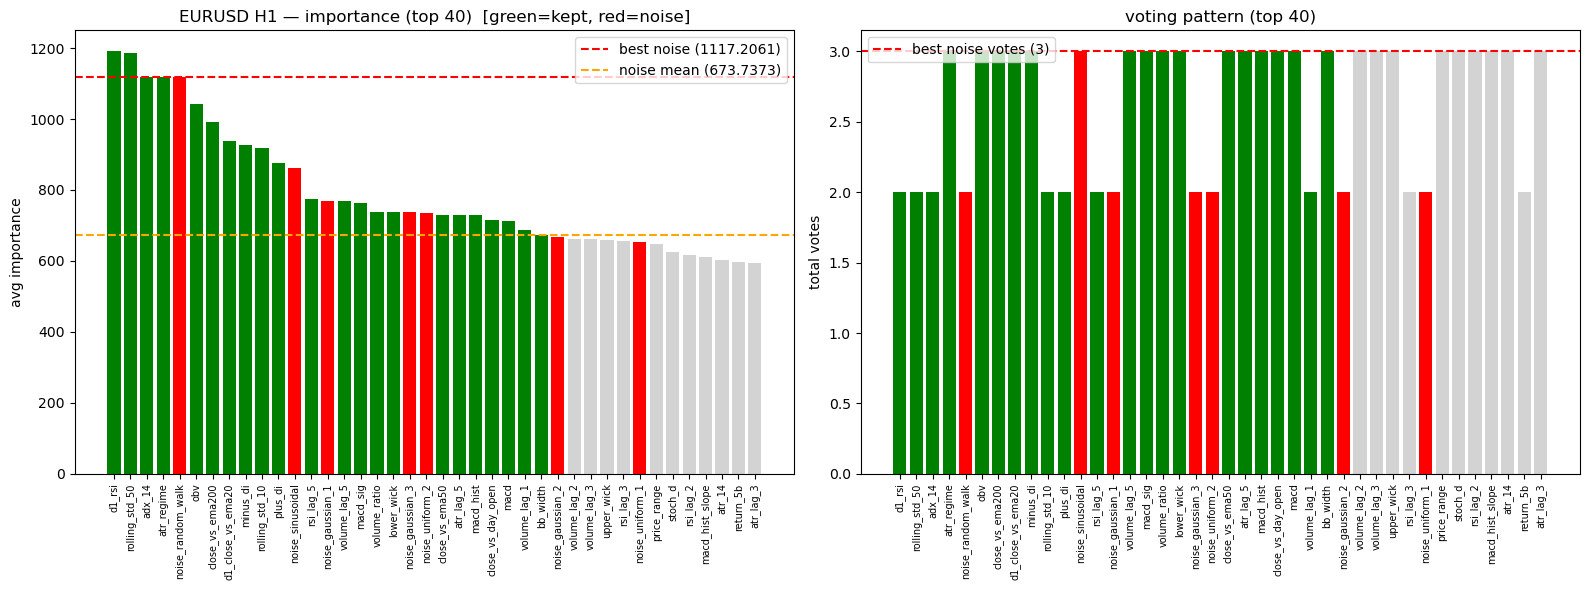

In [18]:
# ── Report ────────────────────────────────────────────────────────────────────
print("=" * 60)
print("FEATURE SELECTION RESULTS")
print("=" * 60)
print(f"Real features tested : {len(feature_cols)}")
print(f"Selected             : {len(selected_features)}")
print(f"Reduction            : {(1 - len(selected_features)/len(feature_cols))*100:.0f}%")
print(f"Best noise importance : {noise_df['avg_imp'].max():.5f}")

selected_report = imp_df[imp_df["feature"].isin(selected_features)]

print("\nTop 15 selected features:")
print(selected_report[["feature", "avg_imp", "total_votes"]].head(15).to_string(index=False))

print("\nNoise feature positions (for reference):")
print(noise_df[["feature", "avg_imp", "total_votes"]].to_string(index=False))

# ── Visualization ─────────────────────────────────────────────────────────────
top = imp_df.head(40)
colors = [
    "green" if f in selected_features else ("red" if noise else "lightgray")
    for f, noise in zip(top["feature"], top["is_noise"])
]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(16, 6))

# Left: average importance, with noise benchmarks
axL.bar(range(len(top)), top["avg_imp"], color=colors)
axL.axhline(noise_df["avg_imp"].max(), color="red", linestyle="--",
            label=f"best noise ({noise_df['avg_imp'].max():.4f})")
axL.axhline(noise_imp_mean, color="orange", linestyle="--",
            label=f"noise mean ({noise_imp_mean:.4f})")
axL.set_xticks(range(len(top)))
axL.set_xticklabels(top["feature"], rotation=90, fontsize=7)
axL.set_ylabel("avg importance")
axL.set_title(f"{PAIR} {TIMEFRAME} — importance (top 40)  [green=kept, red=noise]")
axL.legend()

# Right: votes
axR.bar(range(len(top)), top["total_votes"], color=colors)
axR.axhline(noise_votes_max, color="red", linestyle="--",
            label=f"best noise votes ({noise_votes_max})")
axR.set_xticks(range(len(top)))
axR.set_xticklabels(top["feature"], rotation=90, fontsize=7)
axR.set_ylabel("total votes")
axR.set_title("voting pattern (top 40)")
axR.legend()

plt.tight_layout()
plt.show()


In [19]:
# ── Persist the selection for the training phase ──────────────────────────────
# Save both the chosen list and the full importance report next to the model bin.
FEATURES_DIR = ROOT / "data" / "features"
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

selected_report.to_csv(FEATURES_DIR / f"{PAIR}_{TIMEFRAME}_selected_features.csv", index=False)
imp_df.to_csv(FEATURES_DIR / f"{PAIR}_{TIMEFRAME}_feature_importance_full.csv", index=False)

print(f"✓ Saved {len(selected_features)} selected features to:")
print(f"  {FEATURES_DIR / f'{PAIR}_{TIMEFRAME}_selected_features.csv'}")

# Keep in memory for the next step (model training uses selected_features)
print(f"\nselected_features ready for training ({len(selected_features)} columns).")


✓ Saved 22 selected features to:
  C:\Users\dsosa\Documents\fx-prival\ml-signal-service\data\features\EURUSD_H1_selected_features.csv

selected_features ready for training (22 columns).


In [20]:
selected_report

,feature,rf_imp,lgbm_imp,logreg_imp,is_noise,avg_imp,rf_vote,lgbm_vote,logreg_vote,total_votes
0,d1_rsi,0.013039,1984,0.026144,False,1190.406526,1,1,0,2
1,rolling_std_50,0.013862,1979,0.015238,False,1187.405682,1,1,0,2
2,adx_14,0.013453,1863,0.017661,False,1117.805802,1,1,0,2
3,atr_regime,0.050314,1862,0.267334,False,1117.241828,1,1,1,3
5,obv,0.014340,1739,0.110255,False,1043.415327,1,1,1,3
6,close_vs_ema200,0.013020,1651,0.048744,False,990.608780,1,1,1,3
7,d1_close_vs_ema20,0.013093,1565,0.200501,False,939.023978,1,1,1,3
8,minus_di,0.010730,1545,0.036022,False,927.006821,1,1,1,3
9,rolling_std_10,0.013543,1529,0.021746,False,917.406237,1,1,0,2
10,plus_di,0.010516,1459,0.017904,False,875.404945,1,1,0,2


### 8.2 Model Selection

We pick the best classifier with **nested cross-validation** — an unbiased way to compare models
that also tunes hyperparameters without leaking the validation/test data.

- **Outer CV** — `GroupKFold` by *year* → no year appears in both train and eval within a fold.
- **Inner CV** — `TimeSeriesSplit` → hyperparameter search respects time order.
- **Recency weights** — recent years get more influence (markets drift over time).
- **Optimization metric** — **PR-AUC** (average precision), the right target for an imbalanced,
  precision-focused BUY signal.

Progression: **Logistic Regression** (baseline) → **Random Forest** → **XGBoost** → **LightGBM**.
The model with the best mean outer-fold PR-AUC wins.


In [21]:
# ── Build model matrices from the selected features ───────────────────────────
# Train is used for nested CV, validation for the final check, test stays sealed.
X_train = df_train[selected_features].fillna(0)
y_train = df_train["buy_label"].astype(int)

X_val = df_val[selected_features].fillna(0)
y_val = df_val["buy_label"].astype(int)

X_test = df_test[selected_features].fillna(0)   # held out — not touched until the very end
y_test = df_test["buy_label"].astype(int)

# Year groups for the outer GroupKFold (keeps whole years together)
groups = df_train["datetime"].dt.year.values

# ── Recency sample weights ────────────────────────────────────────────────────
# Recent years matter more — weight decays ~15% per year back in time.
def time_decay_weights(years, decay=0.15):
    years_ago = years.max() - years
    w = np.exp(-decay * years_ago)
    return w * len(w) / w.sum()   # normalise so weights sum to n (sklearn convention)

sample_weights = time_decay_weights(groups)

print(f"Features : {len(selected_features)}")
print(f"Train    : {X_train.shape}  (pos {y_train.mean()*100:.1f}%)")
print(f"Val      : {X_val.shape}  (pos {y_val.mean()*100:.1f}%)")
print(f"Test     : {X_test.shape}  (sealed)")
print(f"Years    : {sorted(set(groups))}")


Features : 22
Train    : (40056, 22)  (pos 24.2%)
Val      : (3648, 22)  (pos 24.4%)
Test     : (2626, 22)  (sealed)
Years    : [np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]


In [22]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, TimeSeriesSplit, RandomizedSearchCV
from xgboost import XGBClassifier

# scale_pos_weight balances XGBoost the way class_weight="balanced" does for the others
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# ── Models + hyperparameter grids ─────────────────────────────────────────────
# Logistic Regression is the baseline (scaled, no tuning). Trees get a search grid.
models = {
    "LogReg": {
        "model": Pipeline([
            ("scale", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
        ]),
        "params": {},   # baseline — no tuning
    },
    "RandomForest": {
        "model": RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
        "params": {
            "n_estimators": [200, 400],
            "max_depth": [8, 12, 20, None],
            "min_samples_leaf": [5, 10, 20],
            "max_features": ["sqrt", 0.5],
        },
    },
    "XGBoost": {
        "model": XGBClassifier(
            random_state=42, n_jobs=-1, tree_method="hist",
            eval_metric="logloss", scale_pos_weight=pos_weight,
        ),
        "params": {
            "max_depth": [3, 4, 5],
            "learning_rate": [0.01, 0.03, 0.05],
            "n_estimators": [300, 500],
            "subsample": [0.7, 0.8],
            "colsample_bytree": [0.7, 0.8],
            "reg_lambda": [1.0, 5.0],
        },
    },
    "LightGBM": {
        "model": lgb.LGBMClassifier(
            class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1,
        ),
        "params": {
            "max_depth": [4, 6, 8],
            "num_leaves": [31, 63],
            "learning_rate": [0.01, 0.03, 0.05],
            "n_estimators": [300, 500],
            "subsample": [0.7, 0.8],
            "colsample_bytree": [0.7, 0.8],
            "reg_lambda": [1.0, 5.0],        # regularisation — prevents overfitting on noisy FX data
            "min_child_samples": [20, 50],   # min samples per leaf — keeps trees from memorising
        },
    },
}

# ── CV strategy ───────────────────────────────────────────────────────────────
OUTER_FOLDS = 5
INNER_FOLDS = 2
SEARCH_ITERS = 20   # random hyperparameter combinations per inner search

outer_cv = GroupKFold(n_splits=OUTER_FOLDS)
inner_cv = TimeSeriesSplit(n_splits=INNER_FOLDS)

print(f"Outer CV : GroupKFold({OUTER_FOLDS}) by year")
print(f"Inner CV : TimeSeriesSplit({INNER_FOLDS})")
print(f"Search   : {SEARCH_ITERS} iters | optimizing PR-AUC (average_precision)")
print(f"XGB scale_pos_weight = {pos_weight:.2f}")


Outer CV : GroupKFold(5) by year
Inner CV : TimeSeriesSplit(2)
Search   : 20 iters | optimizing PR-AUC (average_precision)
XGB scale_pos_weight = 3.13


In [23]:
from sklearn.metrics import average_precision_score


def nested_cv(model, params, X, y, groups, weights, name):
    """
    Nested cross-validation for one classifier.
    Inner loop tunes hyperparameters (RandomizedSearchCV, PR-AUC).
    Outer loop gives an unbiased PR-AUC estimate. Returns scores + best params per fold.
    """
    outer_scores, best_params_per_fold = [], []

    for fold, (tr, te) in enumerate(outer_cv.split(X, y, groups), 1):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]
        w_tr = weights[tr]

        if params:  # tree models — tune hyperparameters on the inner split
            search = RandomizedSearchCV(
                model, params, n_iter=SEARCH_ITERS, cv=inner_cv,
                scoring="average_precision", n_jobs=-1, random_state=42,
            )
            search.fit(X_tr, y_tr, sample_weight=w_tr)
            best = search.best_estimator_
            best_params_per_fold.append(search.best_params_)
        else:       # baseline — no tuning
            best = model.fit(X_tr, y_tr)
            best_params_per_fold.append({})

        # PR-AUC on the untouched outer fold
        proba = best.predict_proba(X_te)[:, 1]
        outer_scores.append(average_precision_score(y_te, proba))
        print(f"   fold {fold}/{OUTER_FOLDS}  PR-AUC = {outer_scores[-1]:.3f}")

    print(f"   → {name}: PR-AUC {np.mean(outer_scores):.3f} ± {np.std(outer_scores):.3f}")
    return {
        "name": name,
        "pr_auc_mean": np.mean(outer_scores),
        "pr_auc_std": np.std(outer_scores),
        "best_params_per_fold": best_params_per_fold,
    }


print("✓ nested_cv() ready")


✓ nested_cv() ready


In [24]:
# ── Run nested CV for every model ─────────────────────────────────────────────
# Note: the tree searches can take a few minutes.
cv_results = {}
for name, cfg in models.items():
    print(f"\n{name}")
    cv_results[name] = nested_cv(
        cfg["model"], cfg["params"], X_train, y_train, groups, sample_weights, name,
    )

# ── Comparison table (higher PR-AUC is better) ────────────────────────────────
comparison = (
    pd.DataFrame([
        {"model": r["name"], "pr_auc": r["pr_auc_mean"], "std": r["pr_auc_std"]}
        for r in cv_results.values()
    ])
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)

# Baseline reference = prevalence (a random model scores ≈ positive rate)
baseline_pr = y_train.mean()

print("\n=== Model comparison (PR-AUC) ===")
print(comparison.round(3).to_string(index=False))
print(f"\nRandom baseline PR-AUC ≈ {baseline_pr:.3f} (positive rate)")

best_model_name = comparison.iloc[0]["model"]
print(f"\n🏆 Best model: {best_model_name}")



LogReg
   fold 1/5  PR-AUC = 0.351
   fold 2/5  PR-AUC = 0.342
   fold 3/5  PR-AUC = 0.339
   fold 4/5  PR-AUC = 0.354
   fold 5/5  PR-AUC = 0.332
   → LogReg: PR-AUC 0.343 ± 0.008

RandomForest
   fold 1/5  PR-AUC = 0.363
   fold 2/5  PR-AUC = 0.334
   fold 3/5  PR-AUC = 0.351
   fold 4/5  PR-AUC = 0.360
   fold 5/5  PR-AUC = 0.342
   → RandomForest: PR-AUC 0.350 ± 0.011

XGBoost
   fold 1/5  PR-AUC = 0.358
   fold 2/5  PR-AUC = 0.334
   fold 3/5  PR-AUC = 0.352
   fold 4/5  PR-AUC = 0.360
   fold 5/5  PR-AUC = 0.341
   → XGBoost: PR-AUC 0.349 ± 0.010

LightGBM
   fold 1/5  PR-AUC = 0.364
   fold 2/5  PR-AUC = 0.328
   fold 3/5  PR-AUC = 0.351
   fold 4/5  PR-AUC = 0.367
   fold 5/5  PR-AUC = 0.341
   → LightGBM: PR-AUC 0.350 ± 0.015

=== Model comparison (PR-AUC) ===
       model  pr_auc   std
    LightGBM   0.350 0.015
RandomForest   0.350 0.011
     XGBoost   0.349 0.010
      LogReg   0.343 0.008

Random baseline PR-AUC ≈ 0.242 (positive rate)

🏆 Best model: LightGBM


In [25]:
# ── Manual model override ─────────────────────────────────────────────────────
# By default the model with the best CV PR-AUC is used automatically.
# To force a different model, set MANUAL_MODEL to one of the names below and
# re-run this cell + everything after it.
#
# Available names (must match exactly):
#   "LogReg"        "RandomForest"        "XGBoost"        "LightGBM"
#
MANUAL_MODEL = "LightGBM"         # ← change to e.g. "LightGBM" to override

# ── Apply override (or keep automatic winner) ─────────────────────────────────
if MANUAL_MODEL is not None:
    if MANUAL_MODEL not in cv_results:
        raise ValueError(f"Unknown model '{MANUAL_MODEL}'. Choose from: {list(cv_results.keys())}")
    best_model_name = MANUAL_MODEL
    print(f"⚠ Manual override active → using {best_model_name}")
else:
    print(f"✓ Auto-selected best model → {best_model_name}")

# Show the CV score for the chosen model
chosen = cv_results[best_model_name]
print(f"\n  CV PR-AUC : {chosen['pr_auc_mean']:.3f} ± {chosen['pr_auc_std']:.3f}")
print(f"\nModel comparison for reference:")
print(comparison.round(3).to_string(index=False))


⚠ Manual override active → using LightGBM

  CV PR-AUC : 0.350 ± 0.015

Model comparison for reference:
       model  pr_auc   std
    LightGBM   0.350 0.015
RandomForest   0.350 0.011
     XGBoost   0.349 0.010
      LogReg   0.343 0.008


In [26]:
from collections import Counter
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, classification_report,
)


def most_frequent_params(params_list):
    """Aggregate the hyperparameters most often chosen across the outer folds."""
    final = {}
    for key in {k for p in params_list for k in p}:
        vals = [p[key] for p in params_list if key in p]
        final[key] = Counter(vals).most_common(1)[0][0]
    return final


# ── Train the winning model on the full training set ──────────────────────────
best_cfg = models[best_model_name]
final_params = most_frequent_params(cv_results[best_model_name]["best_params_per_fold"])

final_model = best_cfg["model"]
if final_params:
    # Tree model — apply best params and train with recency weights
    final_model.set_params(**final_params)
    print(f"Final hyperparameters: {final_params}")
    final_model.fit(X_train, y_train, sample_weight=sample_weights)
else:
    # Baseline LogReg pipeline — no tuning, no sample weights
    final_model.fit(X_train, y_train)

# ── Evaluate on the validation set (2025) ─────────────────────────────────────
val_proba = final_model.predict_proba(X_val)[:, 1]
val_pred  = (val_proba >= 0.5).astype(int)

breakeven = ATR_SL_MULT / (ATR_TP_MULT + ATR_SL_MULT)   # precision the model must beat

print(f"\n=== Validation performance — {best_model_name} ===")
print(f"Precision (BUY) : {precision_score(y_val, val_pred):.3f}   (breakeven ≈ {breakeven:.3f})")
print(f"Recall    (BUY) : {recall_score(y_val, val_pred):.3f}")
print(f"F1        (BUY) : {f1_score(y_val, val_pred):.3f}")
print(f"ROC-AUC         : {roc_auc_score(y_val, val_proba):.3f}")
print(f"PR-AUC          : {average_precision_score(y_val, val_proba):.3f}")

print("\nConfusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_val, val_pred))
print("\n" + classification_report(y_val, val_pred, target_names=["no-buy", "buy"]))


Final hyperparameters: {'max_depth': 8, 'n_estimators': 300, 'learning_rate': 0.01, 'colsample_bytree': 0.7, 'reg_lambda': 5.0, 'subsample': 0.7, 'num_leaves': 31, 'min_child_samples': 50}

=== Validation performance — LightGBM ===
Precision (BUY) : 0.303   (breakeven ≈ 0.400)
Recall    (BUY) : 0.719
F1        (BUY) : 0.427
ROC-AUC         : 0.617
PR-AUC          : 0.317

Confusion matrix (rows=true, cols=pred):
[[1285 1472]
 [ 250  641]]

              precision    recall  f1-score   support

      no-buy       0.84      0.47      0.60      2757
         buy       0.30      0.72      0.43       891

    accuracy                           0.53      3648
   macro avg       0.57      0.59      0.51      3648
weighted avg       0.71      0.53      0.56      3648



### 8.3 Threshold Calibration

Precision at threshold 0.5 is **below the breakeven (0.40)** — the model fires on too many
low-confidence bars. Raising the threshold trades recall for precision.

We scan every threshold and find the one where **precision ≥ breakeven** with the most signals.


Breakeven : 0.400
Optimal threshold   : 0.678
Precision at optimal: 0.400
Recall    at optimal: 0.043
Signals fired       : 95.0 / 3648 (2.6%)
Signals per day     : 0.62

Top 10 viable thresholds (highest recall):
 threshold  precision  recall  n_signals  signals_per_day
     0.678      0.400   0.043         95             0.62
     0.678      0.404   0.043         94             0.62
     0.678      0.409   0.043         93             0.61
     0.678      0.402   0.042         92             0.61
     0.678      0.407   0.042         91             0.60
     0.679      0.411   0.042         90             0.59
     0.679      0.416   0.042         89             0.59
     0.679      0.420   0.042         88             0.58
     0.679      0.414   0.040         87             0.57
     0.679      0.407   0.039         86             0.57


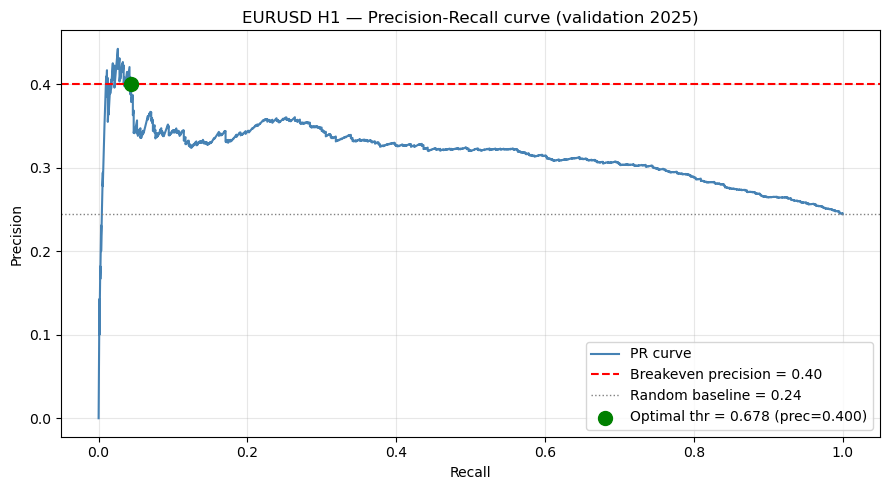

In [27]:
from sklearn.metrics import precision_recall_curve

# Precision-recall curve across all thresholds
precisions, recalls, thresholds = precision_recall_curve(y_val, val_proba)
# Note: precision_recall_curve returns n+1 points; thresholds has n entries
# precisions[-1] == 1.0, recalls[-1] == 0.0 (sentinel point at highest threshold)

# ── Find thresholds that clear the breakeven ──────────────────────────────────
# For each threshold, compute: signals fired, precision, recall, and signal rate per day.
# Validation set = roughly 260 trading days (6216 H1 bars / 24 bars per day).
trading_days = len(y_val) / 24

viable = []
for thr, prec, rec in zip(thresholds, precisions[:-1], recalls[:-1]):
    n_signals  = (val_proba >= thr).sum()
    signals_pd = n_signals / trading_days
    if prec >= breakeven and n_signals > 0:
        viable.append({
            "threshold": round(thr, 3),
            "precision": round(prec, 3),
            "recall":    round(rec, 3),
            "n_signals": int(n_signals),
            "signals_per_day": round(signals_pd, 2),
        })

viable_df = pd.DataFrame(viable)

# ── Pick the optimal threshold ────────────────────────────────────────────────
# Among all thresholds with precision >= breakeven, pick the one with most signals
# (highest recall) — that's the most tradeable configuration.
if not viable_df.empty:
    optimal = viable_df.sort_values("recall", ascending=False).iloc[0]
    OPTIMAL_THRESHOLD = optimal["threshold"]
    print(f"Breakeven : {breakeven:.3f}")
    print(f"Optimal threshold   : {OPTIMAL_THRESHOLD}")
    print(f"Precision at optimal: {optimal['precision']:.3f}")
    print(f"Recall    at optimal: {optimal['recall']:.3f}")
    print(f"Signals fired       : {optimal['n_signals']} / {len(y_val)} ({optimal['n_signals']/len(y_val)*100:.1f}%)")
    print(f"Signals per day     : {optimal['signals_per_day']:.2f}")
    print(f"\nTop 10 viable thresholds (highest recall):")
    print(viable_df.sort_values("recall", ascending=False).head(10).to_string(index=False))
else:
    OPTIMAL_THRESHOLD = 0.5
    print("⚠ No threshold achieves precision ≥ breakeven. Model needs improvement.")
    print("  Possible next steps: better features, different label params, or longer horizon.")

# ── Precision-recall curve plot ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(recalls[:-1], precisions[:-1], color="steelblue", lw=1.5, label="PR curve")
ax.axhline(breakeven, color="red", linestyle="--", lw=1.5, label=f"Breakeven precision = {breakeven:.2f}")
ax.axhline(y_val.mean(), color="gray", linestyle=":", lw=1, label=f"Random baseline = {y_val.mean():.2f}")

if not viable_df.empty:
    ax.scatter(optimal["recall"], optimal["precision"], s=100, zorder=5,
               color="green", label=f"Optimal thr = {OPTIMAL_THRESHOLD} (prec={optimal['precision']:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"{PAIR} {TIMEFRAME} — Precision-Recall curve (validation 2025)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [28]:
import joblib

# ── Save the trained model + the feature list it expects ──────────────────────
# The bundle includes the optimal threshold so inference uses the right cutoff.
model_path = MODELS_DIR / f"{PAIR}_{TIMEFRAME}_buy_{best_model_name}.joblib"
joblib.dump(
    {
        "model": final_model,
        "features": selected_features,
        "threshold": OPTIMAL_THRESHOLD,   # use this, not 0.5, for BUY signals
        "atr_tp_mult": ATR_TP_MULT,
        "atr_sl_mult": ATR_SL_MULT,
        "forward_bars": FORWARD_BARS,
    },
    model_path,
)

print(f"✓ Saved model bundle → {model_path}")
print(f"  model     : {best_model_name}")
print(f"  features  : {len(selected_features)}")
print(f"  threshold : {OPTIMAL_THRESHOLD}  (calibrated for precision ≥ {breakeven:.2f})")


✓ Saved model bundle → C:\Users\dsosa\Documents\fx-prival\ml-signal-service\models_bin\EURUSD_H1_buy_LightGBM.joblib
  model     : LightGBM
  features  : 22
  threshold : 0.678  (calibrated for precision ≥ 0.40)
